# Phase plane analysis of the reduced model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp

import gsc_model_functions as gmf

In [2]:
def s_nullcline(V,delta_s,k,ms,Ps):
  return k - V - (delta_s * k) / ((2*Ps - 1) * ms )

# we have to calculate this numerically as it can only be implicity defined. when this is equal to 0 we are on the V-nullcline
def V_nullcline(V, s, s_pro, s_death, K, Ps, ms):
  return s + V + (s_death * V * K) / (2*(1-Ps)*ms*s + s_pro*V) - K 

In [3]:
# base parameter values we will use
n_ = 10
Ps_ = 0.52
delta_s = 0.001
K = 1
ms_ = 0.2
mv_ = 2 * ms_ * np.ones(n_)
mv_[-1] = 0 
del_v_val = 0.05
delta_v_ = np.ones(n_) * del_v_val

In [4]:
# Set up grid of points
s_values = np.linspace(0.00000001, 1, 101)
V_values = np.linspace(0, 1, 101)

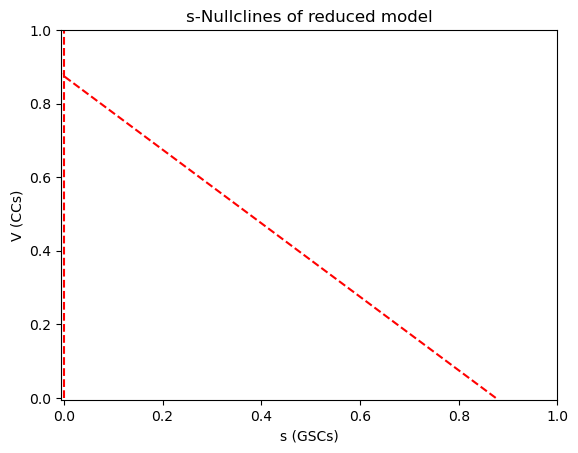

In [5]:
# plot s-nullcline
plt.plot(s_nullcline(V_values,delta_s,K,ms_,Ps_),V_values,'r--', label= None)
plt.plot(np.zeros(len(V_values)), V_values, 'r--',label='s-nullcline')
plt.xlim([-0.005,1])
plt.ylim([-0.005,1])
plt.ylabel("V (CCs)")
plt.xlabel("s (GSCs)")
plt.title("s-Nullclines of reduced model")
plt.show()

In [6]:
V_sol = np.zeros(len(s_values))

s_pro = 0.1
s_death = 0.1

for i in range(len(s_values)):
    V_guess =  s_values[i] # this is just a guess to help the fsolve function find the root faster
    V_sol[i] = fsolve(V_nullcline, V_guess, args=(s_values[i], s_pro, s_death, K, Ps_, ms_))[0]

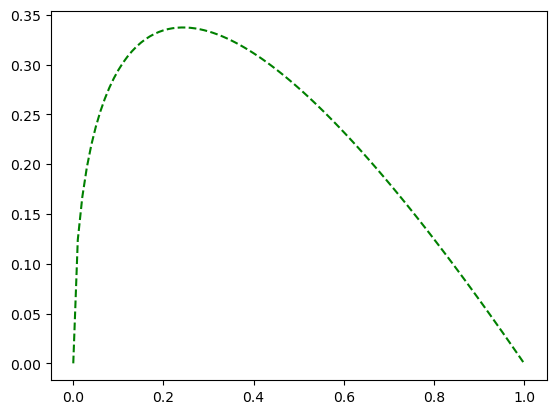

In [7]:
plt.plot(s_values, V_sol, 'g--', label='V-nullcline')


In [8]:
# find equlibrium points
eq_ind = np.where(np.isclose(s_nullcline(V_values,delta_s,K,ms_,Ps_), V_sol, atol=0.002))
print(eq_ind)

print(f's = {s_values[eq_ind]}, V = {V_sol[eq_ind]}')



(array([69], dtype=int64),)
s = [0.69], V = [0.18656095]


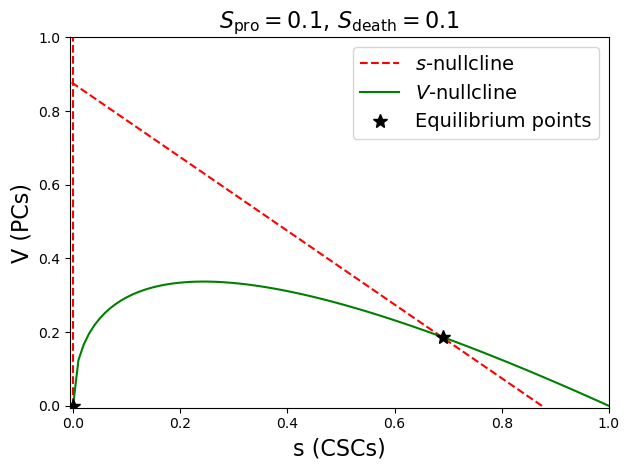

In [9]:
# plot both nullclines together
fig, ax = plt.subplots()
# s-nullclines
ax.plot(s_nullcline(V_values,delta_s,K,ms_,Ps_),V_values,'r--', label= None)
ax.plot(np.zeros(len(V_values)), V_values, 'r--',label='$s$-nullcline')
ax.set_xlim([-0.005,1])
ax.set_ylim([-0.005,1])
ax.set_ylabel("V (PCs)", fontsize = 16)
ax.set_xlabel("s (CSCs)", fontsize = 16)
ax.plot(s_values, V_sol, 'g-', label='$V$-nullcline')
ax.set_title("$S_\\text{pro} = 0.1, \, S_\\text{death} = 0.1$", fontsize = 16)

ax.plot(s_values[eq_ind], V_sol[eq_ind], 'k*', markersize = 10, label='Equilibrium points')
ax.plot(s_values[0], V_sol[0], 'k*', markersize = 10, label=None) # this is just to add the first equilibrium point to the legend

plt.legend(fontsize = 14)

plt.tight_layout()
plt.savefig('Figs/nullclines.pdf', bbox_inches='tight')
plt.show()

In [10]:

# Calulate some trajectories (solutions to the reduced model) to potentially add them to the phase plane plot.
def calc_trajectory(u0, n, Ps, K, ms, mv, delta_s, delta_v):

  # for now just assume this is long enough for equlibrium to be reached
  t_final = 60000

  sol = solve_ivp(gmf.gsc_model_reduced_dudt, [0, t_final], u0, args=(n, Ps, K, ms, mv, delta_s, delta_v))

  s = sol.y[0]
  V = sol.y[1]
  t = sol.t

  return V,s,t

def plot_phase_plane(Ps, n,ms,mv,delta_s,delta_v, ax):
    """
    Function to plot phase plane in a consistent way
    """
    V_values = np.linspace(0, 1, 501)
    s_values = np.linspace(0, 1, 501)
    s_grid, V_grid = np.meshgrid(s_values, V_values)
    #q = np.linspace(0,1,101)
    dsdt, dVdt = gmf.gsc_model_reduced_dudt(0,[s_grid, V_grid],n,Ps,K,ms,mv,delta_s,delta_v)

    # Plot the V-nullcline
    ax.contour(s_grid, V_grid, dVdt, levels=[0], colors='g')
    # Plot the s-nullclines
    ax.plot(s_nullcline(V_values,delta_s,K,ms,Ps), V_values,'--', color = 'red')
    ax.plot( np.zeros(len(V_values)), V_values, '--',color = 'red')


    # Equilibirum point
    u0 = [0.1,0.1]
    example_V, example_s, t = calc_trajectory(u0, n, Ps, K, ms, mv, delta_s, delta_v)
    equlibrium_point = [example_s[-1], example_V[-1]]
    ax.plot(equlibrium_point[0], equlibrium_point[1], 'k*', label='Equlibrium point', markersize = 9)

    # Stream lines
    # Controlling the starting points of the streamlines
    #seed_points = np.array([[0,0.1, 0.2, 0.7], [0.1,0.5,0.1,0.7]])
    #strm = ax.streamplot(s_grid, V_grid, dsdt, dVdt, density = 0.25, color = dVdt, cmap = 'plasma', zorder=0,  broken_streamlines=False)
    strm = ax.streamplot(s_grid, V_grid, dsdt, dVdt, density = 0.5, zorder=0, color = 'Grey',  broken_streamlines=True)
    # Direct way: adjust alpha on returned collections
    strm.lines.set_alpha(0.5)   # streamline curves
    strm.arrows.set_alpha(0.15)  # arrow markers
    #ax.plot(seed_points[0], seed_points[1], 'bo')

    # Add quiver plot
    #ax.quiver(V_grid, s_grid, dVdt, dsdt, color='gray', alpha=0.5)

    '''
    # add example trajectories at a series
    # Define a list of u0 values, (s0, V0)
    u0_values = [
        [0.1, 0.1],
        [0.2, 0.2],
        [0.3, 0.3],
        [0.4, 0.4],
        [0.6,0.02],
        [0.02,0.6]
    ]
    # Loop over each u0 value and plot the trajectory
    for u0 in u0_values:
        example_V, example_s, t = calc_trajectory(u0, n, Ps, K, ms, mv, delta_s, delta_v)
        ax.plot(example_V, example_s, 'g--')
    '''

    ax.set_xlim([-0.01, 1])
    ax.set_ylim([-0.01, 1])

c:\Users\nicho\OneDrive - The University of Nottingham\Nicholas Harbour\BMP4_Bulletin_submission\Code\gsc_model_functions.py:62: RuntimeWarning: divide by zero encountered in divide
  return 2*mv[i-1]*(1-N/k) / (delta_v[i]+mv[i]*(1-N/k))
c:\Users\nicho\OneDrive - The University of Nottingham\Nicholas Harbour\BMP4_Bulletin_submission\Code\gsc_model_functions.py:94: RuntimeWarning: invalid value encountered in add
  numerator = numerator + mv[i]*alpha_product
c:\Users\nicho\OneDrive - The University of Nottingham\Nicholas Harbour\BMP4_Bulletin_submission\Code\gsc_model_functions.py:95: RuntimeWarning: invalid value encountered in add
  denominator = denominator + alpha_product
c:\Users\nicho\OneDrive - The University of Nottingham\Nicholas Harbour\BMP4_Bulletin_submission\Code\gsc_model_functions.py:122: RuntimeWarning: invalid value encountered in add
  numerator = numerator + delta_v[i]*alpha_product
c:\Users\nicho\OneDrive - The University of Nottingham\Nicholas Harbour\BMP4_Bulletin_

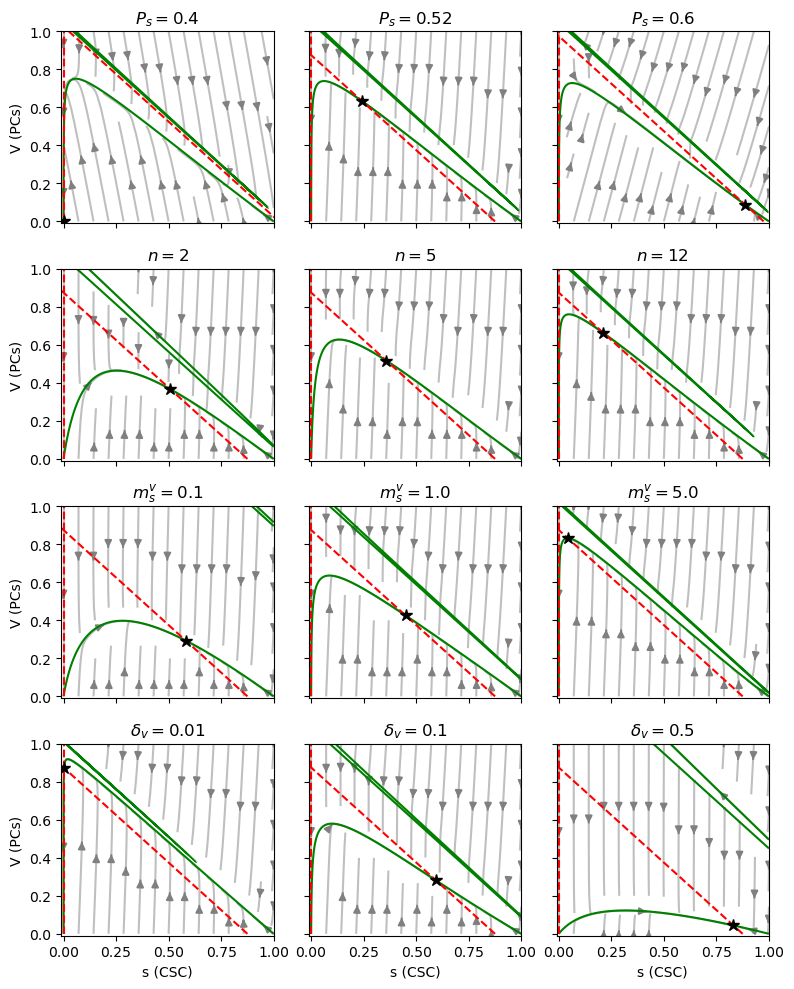

In [11]:
# base parameters used given at the top of notebook

# Varying parameter values
Ps_values = [0.4,0.52,0.6]
n_values = np.array([2,5,12])
mv_values = np.array([ms_*0.1,1*ms_,ms_*5])
delta_v_vals = np.array([0.01,0.1,0.5])


# Set up 3-by-3 figure axes
fig, axs = plt.subplots(4,3, sharex=True, sharey=True, figsize = (8,10))
ax = axs.flatten()

# first row vary Ps keep other parameters at base values
for i in range(3):
    Ps = Ps_values[i]
    title = f"$P_s = {Ps}$"
    plot_phase_plane(Ps, n_, ms_, mv_ , delta_s, delta_v_, ax[i])
    ax[i].set_title(title)

# second row vary n keep other parameters at base values 
for i in range(3,6):
    n = n_values[i-3]
    # When n varies these other parameters much also be redefined as they depend on n
    mv = 2*ms_ * np.ones(n)
    mv[-1] = 0
    delta_v = np.ones(n) * del_v_val
    title = f"$n = {n}$"
    plot_phase_plane(Ps_, n, ms_, mv , delta_s, delta_v, ax[i])
    ax[i].set_title(title)

# third row vary mv keep other parameters at base values
for i in range(6,9):
    mv = mv_values[i-6] * np.ones(n_)
    mv[-1] = 0
    title = f"$m^v_s  ={(mv[0]/ms_):.1f}$"
    plot_phase_plane(Ps_, n_, ms_, mv , delta_s, delta_v_, ax[i])
    ax[i].set_title(title)

# fourth row vary delta_v keep other parameters at base values
for i in range(9,12):
    delta_v = delta_v_vals[i-9]*np.ones(n_)
    title = f"$\delta_v = {delta_v[0]}$"
    plot_phase_plane(Ps_, n_, ms_, mv_ , delta_s, delta_v, ax[i])
    ax[i].set_title(title)


for i in range(12):
    if i % 3 == 0:
      ax[i].set_ylabel("V (PCs)")
    
    if i > 8:
      ax[i].set_xlabel("s (CSC)")


fig.tight_layout()
plt.savefig("Figs/Phase_plane.pdf", bbox_inches="tight")